In [17]:
# Map short station names to full names
station_map = {
    "hsg": "Huangshuigou",
    "dsk": "Dashankou",
    "xhl": "Xiehela",
    "slglk": "Shaliguilanke",
    "kq": "Kaqun",
    "wlwt": "Wuluwati",
    "tgzlk": "Tongguziluoke"
}

df["Station_Full"] = df["Station"].map(station_map)

# Desired order
stations = [
    "Huangshuigou",
    "Dashankou",
    "Xiehela",
    "Shaliguilanke",
    "Kaqun",
    "Wuluwati",
    "Tongguziluoke"
]

scenarios = ["ssp126", "ssp245", "ssp370", "ssp585"]
gcms = sorted(df["GCM"].unique())


In [ ]:
import re
import pandas as pd

file_path = r"F:\geodata\river_runoff_obs\output\daily_note_2025-01-03_22-52-24_fixed.txt"

pattern = re.compile(
    r"Name:\s*(?P<Name>[^,]+).*?"
    r"Scenario:\s*(?P<Scenario>[^,]+).*?"
    r"GCM:\s*(?P<GCM>[^,]+).*?"
    r"Pbias:\s*(?P<Pbias>[-\d\.]+)",
    re.IGNORECASE
)

records = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            d = match.groupdict()
            # Extract station name from first part (e.g., "1_hsg_imputMF")
            # Extract station name (the second part, index 1)
            parts = d["Name"].split("_")
            d["Station"] = parts[1]   # e.g., "tgzlk"

            d["Pbias"] = float(d["Pbias"])
            records.append(d)

df = pd.DataFrame(records)

In [23]:
df


,Name,Scenario,GCM,Pbias,Station
0,1_hsg_imputMF_MPI-ESM1-2-HR_ssp126_r1i1p1f1_daily,ssp126,MPI-ESM1-2-HR,13.343807,hsg
1,1_hsg_imputMF_MPI-ESM1-2-HR_ssp126_r1i1p1f1_daily,ssp126,MPI-ESM1-2-HR,9.937157,hsg
2,1_hsg_imputMF_MPI-ESM1-2-HR_ssp126_r1i1p1f1_daily,ssp126,MPI-ESM1-2-HR,13.299356,hsg
3,1_hsg_imputMF_MPI-ESM1-2-HR_ssp126_r1i1p1f1_daily,ssp126,MPI-ESM1-2-HR,96.567716,hsg
4,1_hsg_imputMF_MPI-ESM1-2-HR_ssp126_r1i1p1f1_daily,ssp126,MPI-ESM1-2-HR,-3.199598,hsg
...,...,...,...,...,...
1171,7_tgzlk_imputMF_INM-CM4-8_ssp585_r1i1p1f1_daily,ssp585,INM-CM4-8,-31.791985,tgzlk
1172,7_tgzlk_imputMF_INM-CM4-8_ssp585_r1i1p1f1_daily,ssp585,INM-CM4-8,-3.043175,tgzlk
1173,7_tgzlk_imputMF_INM-CM4-8_ssp585_r1i1p1f1_daily,ssp585,INM-CM4-8,96.028824,tgzlk
1174,7_tgzlk_imputMF_INM-CM4-8_ssp585_r1i1p1f1_daily,ssp585,INM-CM4-8,-16.349735,tgzlk


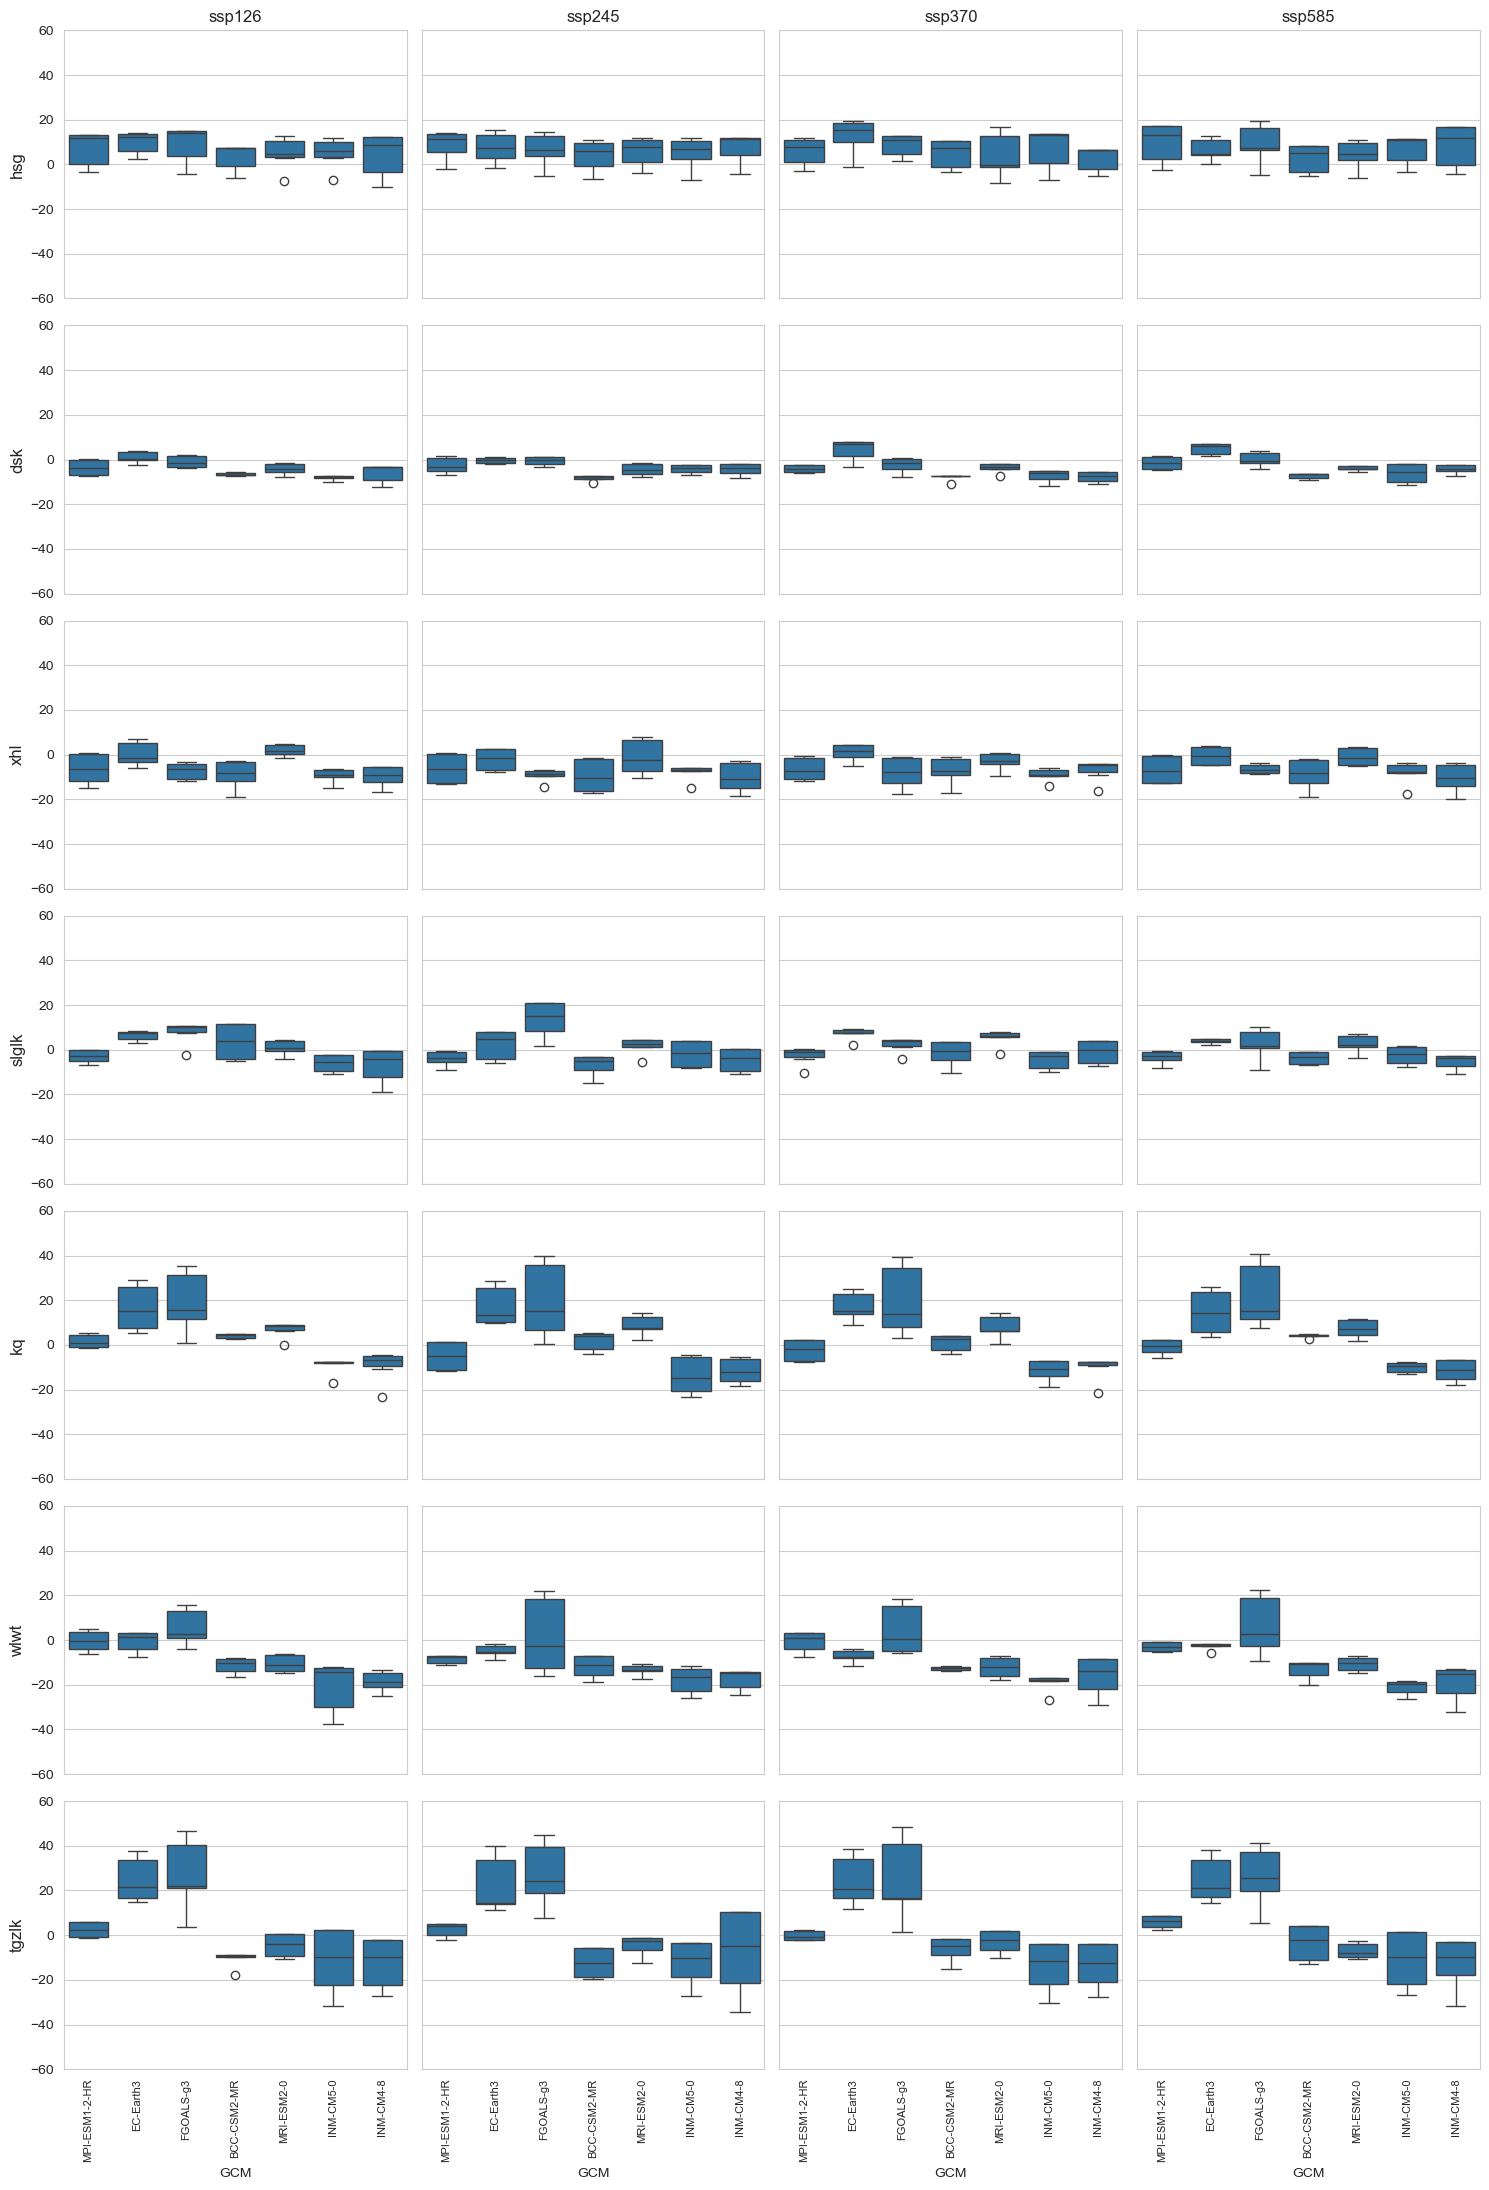

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

stations = ['hsg','dsk','xhl','slglk','kq','wlwt','tgzlk']
scenarios = ["ssp126", "ssp245", "ssp370", "ssp585"]
gcms = ['MPI-ESM1-2-HR','EC-Earth3', 'FGOALS-g3','INM-CM5-0','INM-CM4-8','MRI-ESM2-0','BCC-CSM2-MR']              # 7 GCMs

fig, axes = plt.subplots(
    nrows=len(stations),
    ncols=len(scenarios),
    figsize=(15, 22),
    sharex=False,
    sharey=True
)

for i, station in enumerate(stations):
    for j, scenario in enumerate(scenarios):

        ax = axes[i, j]
        subset = df[(df["Station"] == station) &
                    (df["Scenario"] == scenario)]

        sns.boxplot(
            data=subset,
            x="GCM",
            y="Pbias",
            ax=ax
        )

        ax.set_ylim(-60, 60)


        # Titles on top row
        if i == 0:
            ax.set_title(scenario, fontsize=12)
        else:
            ax.set_title('')

        # Y-axis labels on left column
        if j == 0:
            ax.set_ylabel(station, fontsize=12)
        else:
            ax.set_ylabel("")

        # Remove x labels for all rows except last
        if i < len(stations) - 1:
            ax.set_xticklabels([])
            ax.set_xlabel("")
        else:
            ax.tick_params(axis='x', labelrotation=90, labelsize=8)

plt.tight_layout()
plt.show()
